In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
print(tf.__version__)

/Users/dipendra10/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


2.16.2


In [ ]:

dataset_path = "/Users/dipendra10/Desktop/nabin/raw-img"


In [ ]:
import os
classes = os.listdir(dataset_path)
print("Classes:", classes)

Classes: ['cat', 'butterfly', 'ai_ml_animal_classification.ipynb', 'dog', 'sheep', 'spider', 'chicken', 'horse', 'squirrel', 'cow', 'elephant']


In [ ]:
for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    print(f"{cls}: {len(os.listdir(class_path))}")

cat: 1668
butterfly: 2112
dog: 4863
sheep: 1820
spider: 4821
chicken: 3098
horse: 2639
squirrel: 1862
cow: 1869
elephant: 1457


In [ ]:
import os

mapping = {
    "cane": "dog",
    "gatto": "cat",
    "elefante": "elephant",
    "mucca": "cow",
    "pecora": "sheep",
    "scoiattolo": "squirrel",
    "farfalla": "butterfly",
    "ragno": "spider",
    "gallina": "chicken",
    "cavallo": "horse"
}

for old_name, new_name in mapping.items():
    old_path = os.path.join(dataset_path, old_name)
    new_path = os.path.join(dataset_path, new_name)

    if os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"Renamed {old_name} → {new_name}")


In [ ]:
classes = os.listdir(dataset_path)
print(classes)

['cat', 'butterfly', 'ai_ml_animal_classification.ipynb', 'dog', 'sheep', 'spider', 'chicken', 'horse', 'squirrel', 'cow', 'elephant']


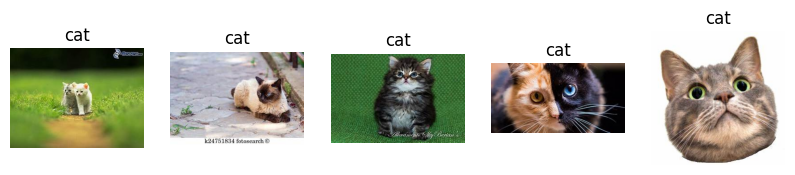

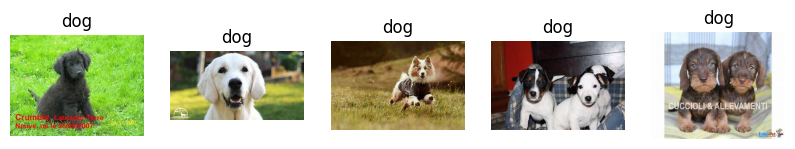

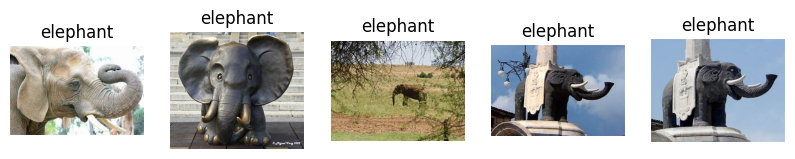

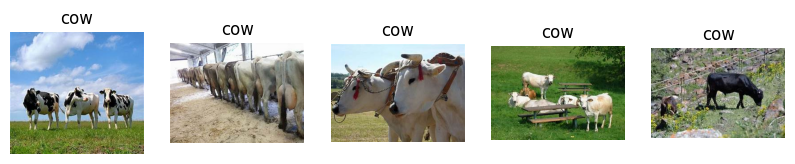

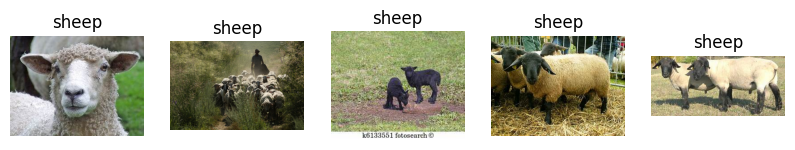

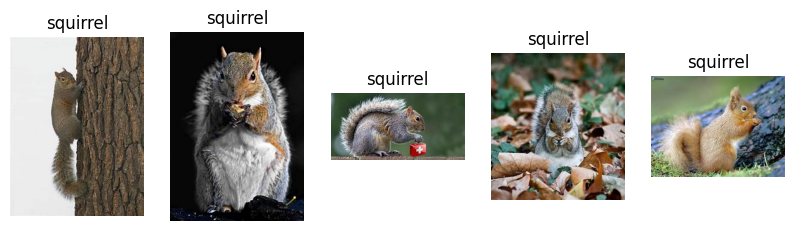

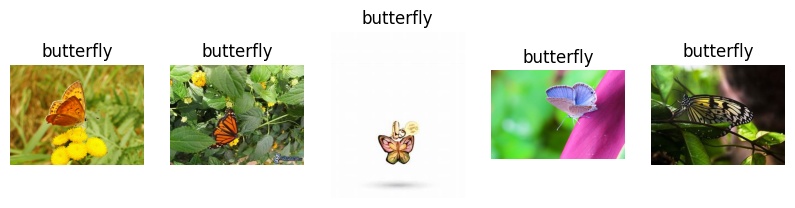

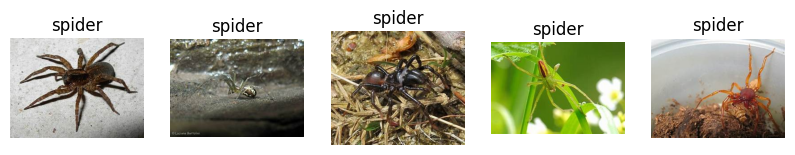

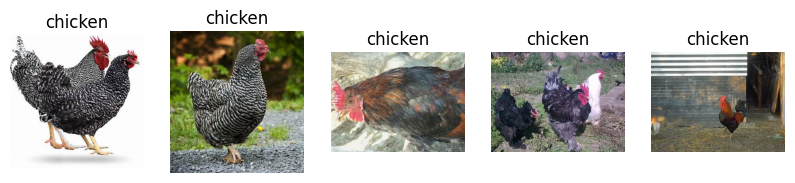

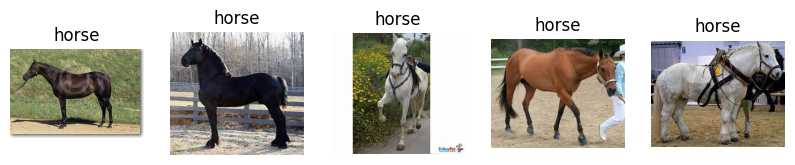

In [ ]:
import matplotlib.pyplot as plt
import random

def show_samples(class_name):
    path = os.path.join(dataset_path, class_name)
    images = random.sample(os.listdir(path), 5)

    plt.figure(figsize=(10,5))

    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = plt.imread(img_path)

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

    plt.show()

# Example
show_samples("cat")
show_samples("dog")
show_samples("elephant")
show_samples("cow")
show_samples("sheep")
show_samples("squirrel")
show_samples("butterfly")
show_samples("spider")
show_samples("chicken")
show_samples("horse")

Import TensorFlow Tools

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Define Image & Batch Size

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

Create Data Generator

In [ ]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    width_shift_range=0.2,

    height_shift_range=0.2
)

Load TRAIN Dataset

In [ ]:
train_data = train_datagen.flow_from_directory(

    dataset_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

Found 20972 images belonging to 10 classes.


Load VALIDATION Dataset

In [ ]:
val_data = train_datagen.flow_from_directory(

    dataset_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation'
)

Found 5237 images belonging to 10 classes.


STEP 2 — BUILD BASELINE CNN MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.summary()

/Users/dipendra10/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-10 13:14:24.648726: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-05-10 13:14:24.648763: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-05-10 13:14:24.648767: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-05-10 13:14:24.649002: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-10 13:14:24.649021: I tensorflow/core/common_runtime/pluggable_device/pluggable_device

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,171,146 (42.61 MB)

 Trainable params: 11,170,698 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

COMPILE MODEL

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EARLY STOPPING

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

TRAIN MODEL

In [ ]:
history = model.fit(

    train_data,

    validation_data=val_data,

    epochs=20,

    callbacks=[early_stop]
)

/Users/dipendra10/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


2026-05-10 13:14:38.447559: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


656/656 ━━━━━━━━━━━━━━━━━━━━ 132s 199ms/step - accuracy: 0.1695 - loss: 114.3463 - val_accuracy: 0.2895 - val_loss: 31.6101
Epoch 2/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 124s 189ms/step - accuracy: 0.2153 - loss: 29.2701 - val_accuracy: 0.1749 - val_loss: 8.9093
Epoch 3/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 122s 186ms/step - accuracy: 0.2100 - loss: 7.7388 - val_accuracy: 0.2268 - val_loss: 6.1348
Epoch 4/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 317s 484ms/step - accuracy: 0.2261 - loss: 6.8052 - val_accuracy: 0.2163 - val_loss: 5.5539
Epoch 5/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 124s 188ms/step - accuracy: 0.2516 - loss: 6.3403 - val_accuracy: 0.3361 - val_loss: 4.7033
Epoch 6/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 124s 189ms/step - accuracy: 0.2675 - loss: 6.5815 - val_accuracy: 0.3878 - val_loss: 3.2665
Epoch 7/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 157s 239ms/step - accuracy: 0.2699 - loss: 7.2577 - val_accuracy: 0.2885 - val_loss: 6.7492
Epoch 8/20
656/656 ━━━━━━━━━━━━━━━━━━━━ 122s 187ms/step - accuracy: 0.2833 - loss: 

Save Model

Visualization after Model Training

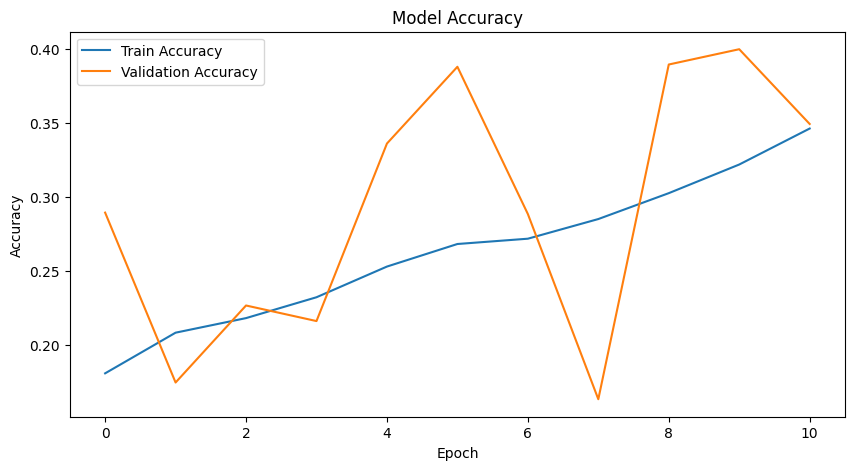

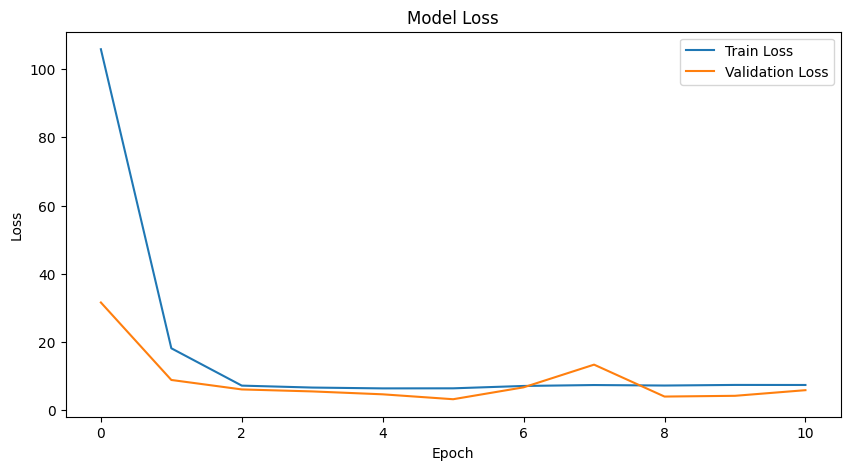

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# Loss Graph
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

CNN with Adam Model Deeper Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import pickle

In [ ]:
dataset_path = "/Users/dipendra10/Desktop/nabin/raw-img"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(

    dataset_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

val_data = train_datagen.flow_from_directory(

    dataset_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation'
)

Found 20972 images belonging to 10 classes.
Found 5237 images belonging to 10 classes.


In [ ]:
model_adam = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

In [ ]:
model_adam.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True
)

In [ ]:
history_adam = model_adam.fit(

    train_data,

    validation_data=val_data,

    epochs=10,

    callbacks=[early_stop]
)

Epoch 1/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 127s 191ms/step - accuracy: 0.2201 - loss: 2.6394 - val_accuracy: 0.2184 - val_loss: 3.5016
Epoch 2/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 126s 192ms/step - accuracy: 0.3371 - loss: 1.9784 - val_accuracy: 0.3515 - val_loss: 1.8685
Epoch 3/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 315s 481ms/step - accuracy: 0.4537 - loss: 1.5948 - val_accuracy: 0.4474 - val_loss: 1.5871
Epoch 4/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 222s 338ms/step - accuracy: 0.5266 - loss: 1.3984 - val_accuracy: 0.4928 - val_loss: 1.5234
Epoch 5/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 130s 198ms/step - accuracy: 0.5835 - loss: 1.2479 - val_accuracy: 0.5209 - val_loss: 1.4106
Epoch 6/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 125s 190ms/step - accuracy: 0.6137 - loss: 1.1666 - val_accuracy: 0.4991 - val_loss: 1.4924
Epoch 7/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 135s 206ms/step - accuracy: 0.6476 - loss: 1.0739 - val_accuracy: 0.5587 - val_loss: 1.4254
Epoch 8/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 123s 188ms/step - accuracy: 0.6772 -

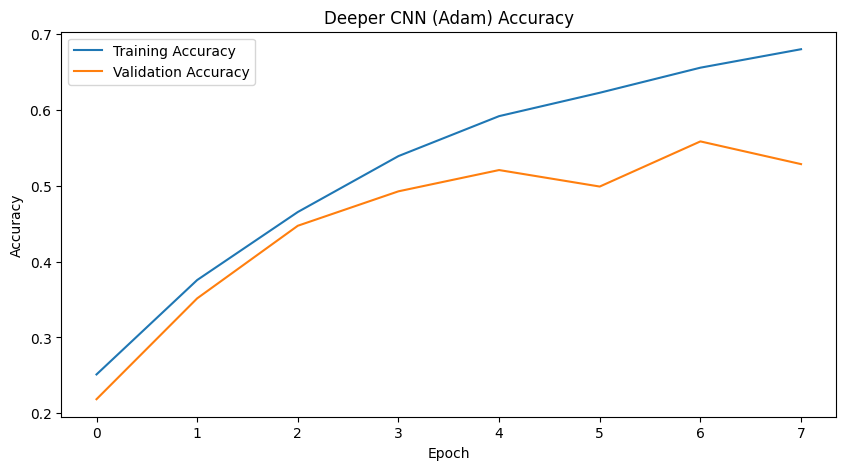

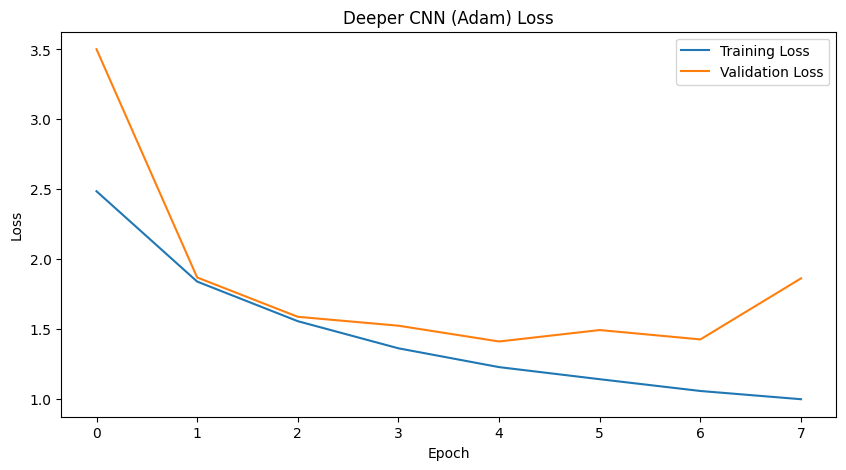

In [ ]:
# Accuracy Plot

plt.figure(figsize=(10,5))

plt.plot(history_adam.history['accuracy'],
         label='Training Accuracy')

plt.plot(history_adam.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Deeper CNN (Adam) Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()
# Loss Plot

plt.figure(figsize=(10,5))

plt.plot(history_adam.history['loss'],
         label='Training Loss')

plt.plot(history_adam.history['val_loss'],
         label='Validation Loss')

plt.title('Deeper CNN (Adam) Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

In [ ]:
model_adam.save("/Users/dipendra10/Desktop/deeper_cnn_adam.keras")

Next Model

In [ ]:
from tensorflow.keras.optimizers import SGD

model_sgd = model_adam

model_sgd.compile(

    optimizer=SGD(learning_rate=0.001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
history_sgd = model_sgd.fit(

    train_data,

    validation_data=val_data,

    epochs=10,

    callbacks=[early_stop]
)

Epoch 1/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 141s 213ms/step - accuracy: 0.6744 - loss: 0.9975 - val_accuracy: 0.7096 - val_loss: 0.8838
Epoch 2/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 143s 218ms/step - accuracy: 0.6844 - loss: 0.9524 - val_accuracy: 0.7098 - val_loss: 0.8705
Epoch 3/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 124s 188ms/step - accuracy: 0.6890 - loss: 0.9456 - val_accuracy: 0.7073 - val_loss: 0.8699
Epoch 4/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 122s 187ms/step - accuracy: 0.6923 - loss: 0.9236 - val_accuracy: 0.7195 - val_loss: 0.8483
Epoch 5/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 122s 186ms/step - accuracy: 0.6944 - loss: 0.9313 - val_accuracy: 0.7141 - val_loss: 0.8654
Epoch 6/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 125s 191ms/step - accuracy: 0.7027 - loss: 0.9019 - val_accuracy: 0.7073 - val_loss: 0.8724
Epoch 7/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 120s 183ms/step - accuracy: 0.6948 - loss: 0.9287 - val_accuracy: 0.7159 - val_loss: 0.8466
Epoch 8/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 121s 184ms/step - accuracy: 0.7022 -

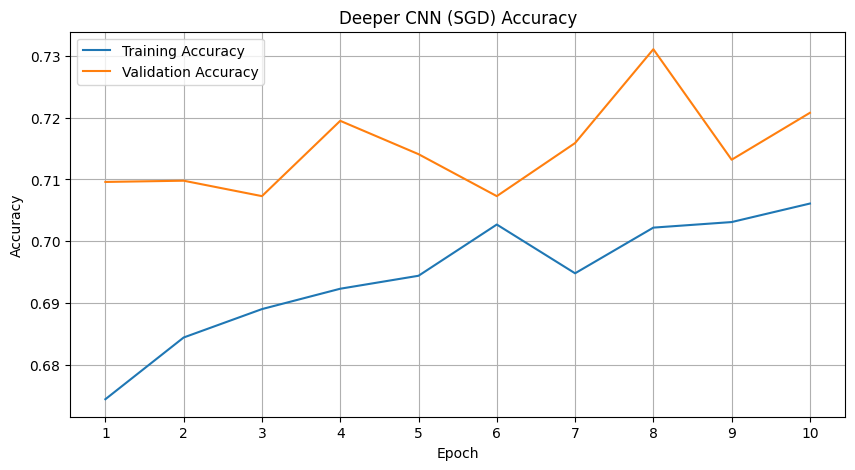

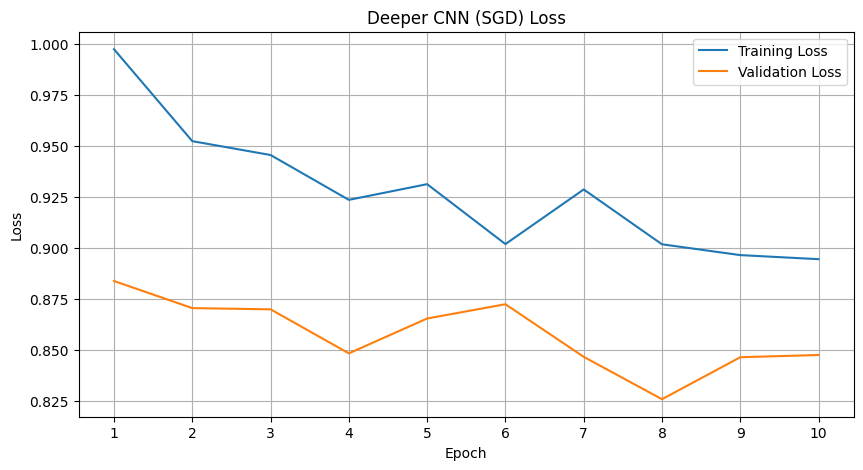

In [ ]:
import matplotlib.pyplot as plt

# Manually entered values from training logs

train_acc = [0.6744, 0.6844, 0.6890, 0.6923, 0.6944,
             0.7027, 0.6948, 0.7022, 0.7031, 0.7061]

val_acc = [0.7096, 0.7098, 0.7073, 0.7195, 0.7141,
           0.7073, 0.7159, 0.7311, 0.7132, 0.7208]

train_loss = [0.9975, 0.9524, 0.9456, 0.9236, 0.9313,
              0.9019, 0.9287, 0.9018, 0.8965, 0.8945]

val_loss = [0.8838, 0.8705, 0.8699, 0.8483, 0.8654,
            0.8724, 0.8466, 0.8258, 0.8464, 0.8475]

epochs = range(1, 11)

# Accuracy Plot
plt.figure(figsize=(10,5))

plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

plt.title('Deeper CNN (SGD) Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()


# Loss Plot
plt.figure(figsize=(10,5))

plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.title('Deeper CNN (SGD) Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model_sgd.save("/Users/dipendra10/Desktop/deeper_cnn_sgd.keras")

Transfer Learning with MobileNetV2

Imports

In [ ]:
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

Load Pretrained MobileNetV2

In [ ]:
base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

2026-05-09 14:44:49.927877: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-05-09 14:44:49.927925: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-05-09 14:44:49.927931: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-05-09 14:44:49.928002: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-09 14:44:49.928021: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Freeze Base Model

In [ ]:
base_model.trainable = False

Build Transfer Learning Model

In [ ]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Compile Model

In [ ]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

Early Stopping

In [ ]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/Users/dipendra10/Desktop/raw-img"


IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    width_shift_range=0.2,

    height_shift_range=0.2
)

train_data = train_datagen.flow_from_directory(

    dataset_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

val_data = train_datagen.flow_from_directory(

    dataset_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation'
)

Found 20972 images belonging to 10 classes.
Found 5237 images belonging to 10 classes.


Train Model

In [ ]:
history = model.fit(

    train_data,

    validation_data=val_data,

    epochs=10,

    callbacks=[early_stop]
)

/Users/dipendra10/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


2026-05-09 14:48:20.366534: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


656/656 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.7189 - loss: 1.1917 - val_accuracy: 0.9229 - val_loss: 0.3101
Epoch 2/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 108s 164ms/step - accuracy: 0.8746 - loss: 0.5500 - val_accuracy: 0.9206 - val_loss: 0.2954
Epoch 3/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 105s 160ms/step - accuracy: 0.8897 - loss: 0.4496 - val_accuracy: 0.9198 - val_loss: 0.2886
Epoch 4/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 106s 162ms/step - accuracy: 0.8991 - loss: 0.3818 - val_accuracy: 0.9374 - val_loss: 0.2211
Epoch 5/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 110s 168ms/step - accuracy: 0.9019 - loss: 0.3518 - val_accuracy: 0.9274 - val_loss: 0.2458
Epoch 6/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 104s 159ms/step - accuracy: 0.9049 - loss: 0.3304 - val_accuracy: 0.9267 - val_loss: 0.2347
Epoch 7/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 102s 155ms/step - accuracy: 0.9043 - loss: 0.3201 - val_accuracy: 0.9345 - val_loss: 0.2226


Plot Accuracy & Loss

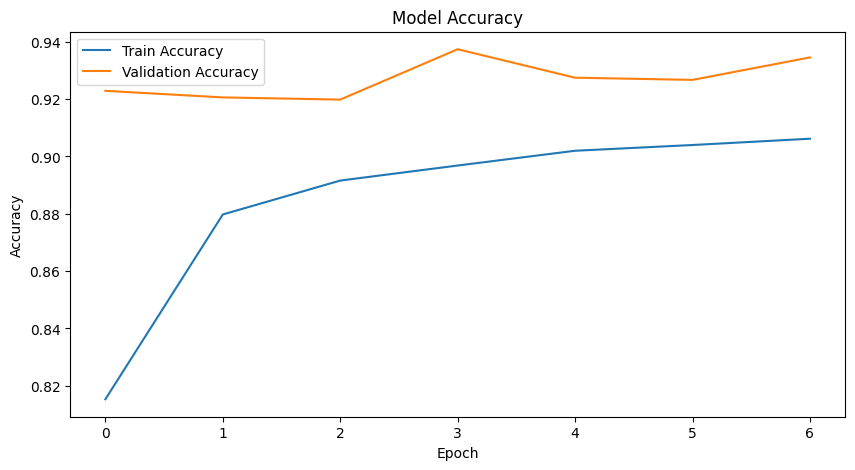

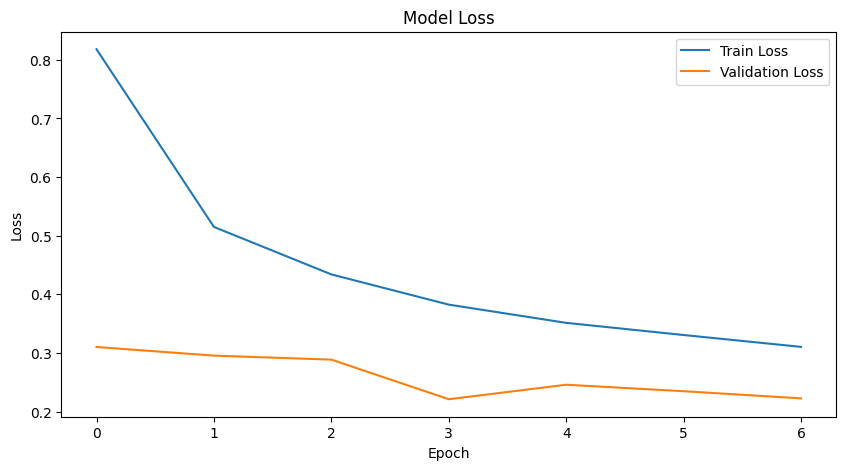

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()


# Loss Plot
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [ ]:
model.save(
    "/Users/dipendra10/Desktop/mobilenetv2_animals.keras"
)

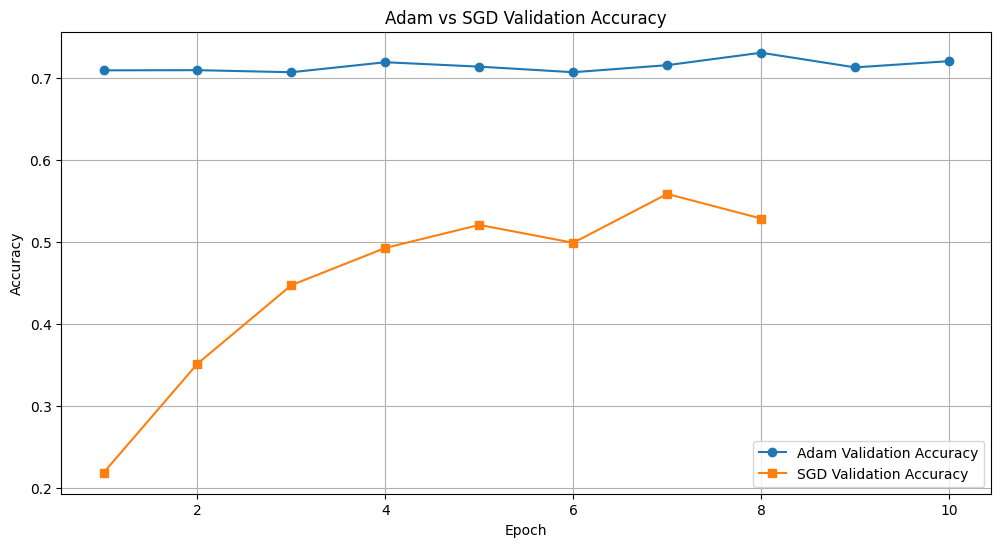

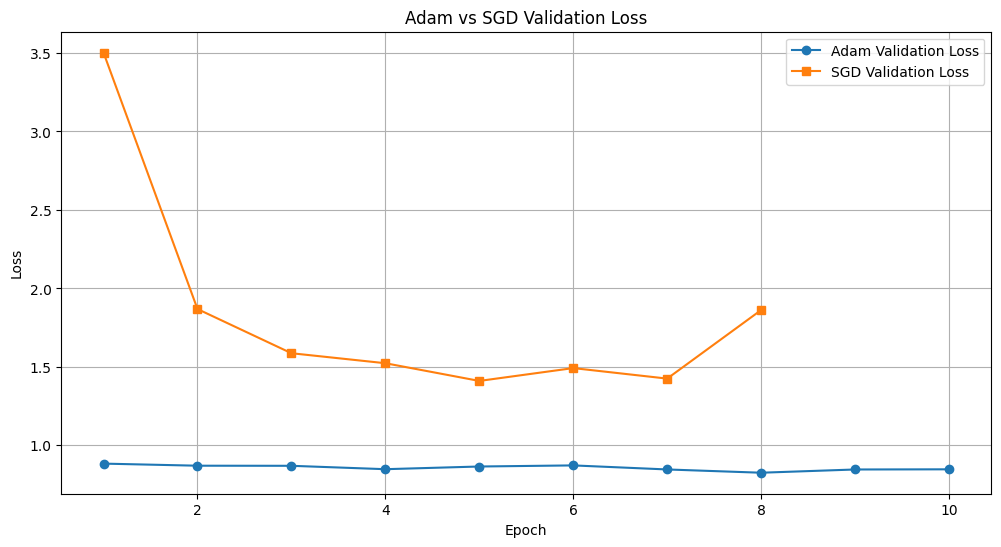

In [ ]:
import matplotlib.pyplot as plt

# =========================================
# Adam Model Data
# =========================================

adam_val_acc = [0.7096, 0.7098, 0.7073, 0.7195, 0.7141,
                0.7073, 0.7159, 0.7311, 0.7132, 0.7208]

adam_val_loss = [0.8838, 0.8705, 0.8699, 0.8483, 0.8654,
                 0.8724, 0.8466, 0.8258, 0.8464, 0.8475]


# =========================================
# SGD Model Data
# =========================================

sgd_val_acc = [0.2184, 0.3515, 0.4474, 0.4928,
               0.5209, 0.4991, 0.5587, 0.5287]

sgd_val_loss = [3.5016, 1.8685, 1.5871, 1.5234,
                1.4106, 1.4924, 1.4254, 1.8622]


# Epochs
epochs_adam = range(1, 11)
epochs_sgd = range(1, 9)


# =========================================
# Validation Accuracy Comparison
# =========================================

plt.figure(figsize=(12,6))

plt.plot(epochs_adam, adam_val_acc,
         marker='o',
         label='Adam Validation Accuracy')

plt.plot(epochs_sgd, sgd_val_acc,
         marker='s',
         label='SGD Validation Accuracy')

plt.title('Adam vs SGD Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()


# =========================================
# Validation Loss Comparison
# =========================================

plt.figure(figsize=(12,6))

plt.plot(epochs_adam, adam_val_loss,
         marker='o',
         label='Adam Validation Loss')

plt.plot(epochs_sgd, sgd_val_loss,
         marker='s',
         label='SGD Validation Loss')

plt.title('Adam vs SGD Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

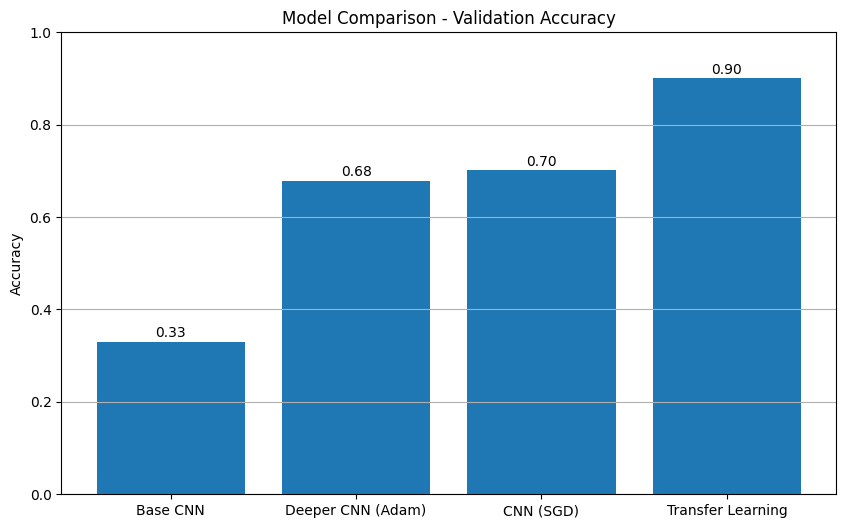

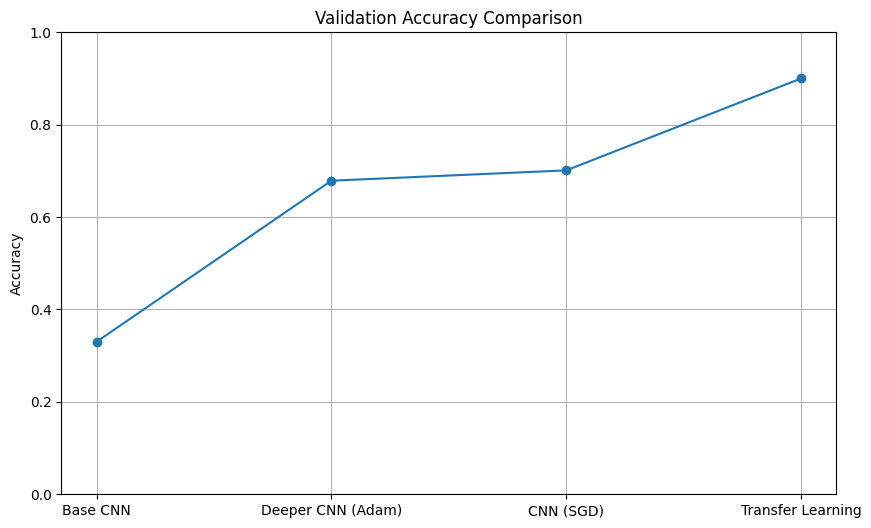

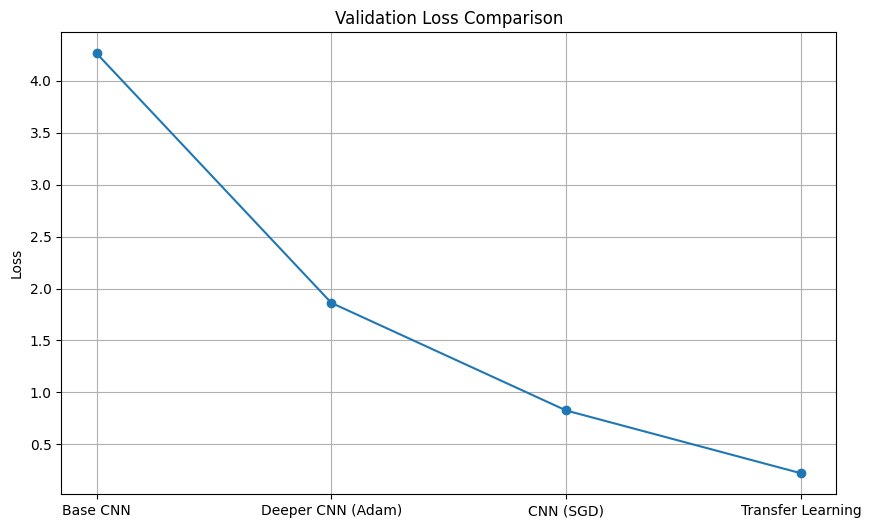

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# FINAL VALIDATION ACCURACIES (CORRECTED)

models = [
    "Base CNN",
    "Deeper CNN (Adam)",
    "CNN (SGD)",
    "Transfer Learning"
]

# Corrected from your logs
val_acc = [
    0.33,   # Base CNN (from earlier log)
    0.6787,   # Deeper CNN (Adam) -> last epoch approx
    0.7011,   # SGD model (best epoch)
    0.90    # Transfer Learning
]

val_loss = [
    4.2660,   # Base CNN
    1.8622,   # Deeper CNN (Adam)
    0.8258,   # SGD
    0.2211    # Transfer Learning
]

# BAR GRAPH - ACCURACY
# ======================================================

plt.figure(figsize=(10,6))

bars = plt.bar(models, val_acc)

plt.title("Model Comparison - Validation Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for bar, acc in zip(bars, val_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{acc:.2f}",
             ha='center')

plt.grid(axis='y')
plt.show()


# ======================================================
# LINE GRAPH - ACCURACY
# ======================================================

plt.figure(figsize=(10,6))

plt.plot(models, val_acc, marker='o')

plt.title("Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.grid(True)
plt.show()


# ======================================================
# LOSS COMPARISON
# ======================================================

plt.figure(figsize=(10,6))

plt.plot(models, val_loss, marker='o')

plt.title("Validation Loss Comparison")
plt.ylabel("Loss")

plt.grid(True)
plt.show()